In [1]:
print("hello world")

hello world


# Mathematical Transformer

In [5]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [7]:
df=pd.read_csv("../../understanding-data/train.csv",usecols=["Age", "Fare","Survived"])
df.sample(5)

,Survived,Age,Fare
424,0,18.0,20.2125
313,0,28.0,7.8958
674,0,NaN,0.0000
614,0,35.0,8.0500
791,0,16.0,26.0000


In [8]:
df["Age"].fillna(df["Age"].mean(),inplace=True)

/var/folders/x4/dcd672b95h70g_8b6vm4lcp40000gn/T/ipykernel_5474/2595122914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


In [10]:
x=df.iloc[:,1:3]
y= df.iloc[:,0]

In [11]:
x_train, x_test, y_train, y_test =train_test_split(x,y,test_size=0.2,random_state=42)

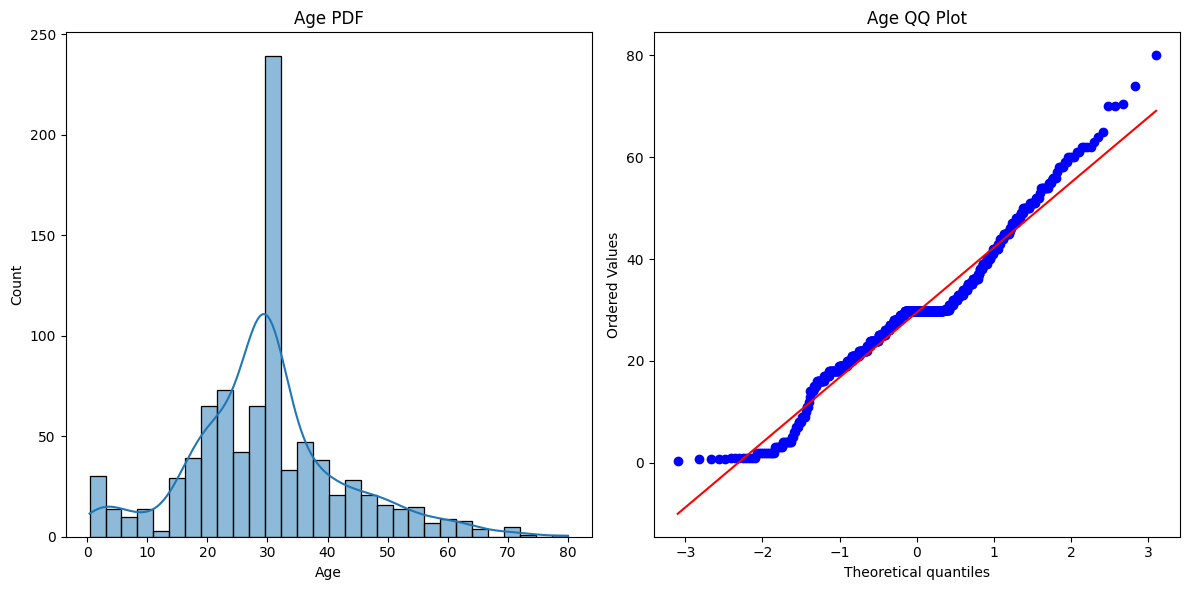

In [19]:
plt.figure(figsize=(12, 6))  # ✅ Correct usage
plt.subplot(121)  # ✅ First subplot
sns.histplot(df["Age"], kde=True)  # Using histplot instead of displot for subplot compatibility
plt.title("Age PDF")

plt.subplot(122)  # ✅ Second subplot
stats.probplot(x_train["Age"], dist="norm", plot=plt)
plt.title("Age QQ Plot")

plt.tight_layout()  # Optional: to avoid overlap
plt.show()

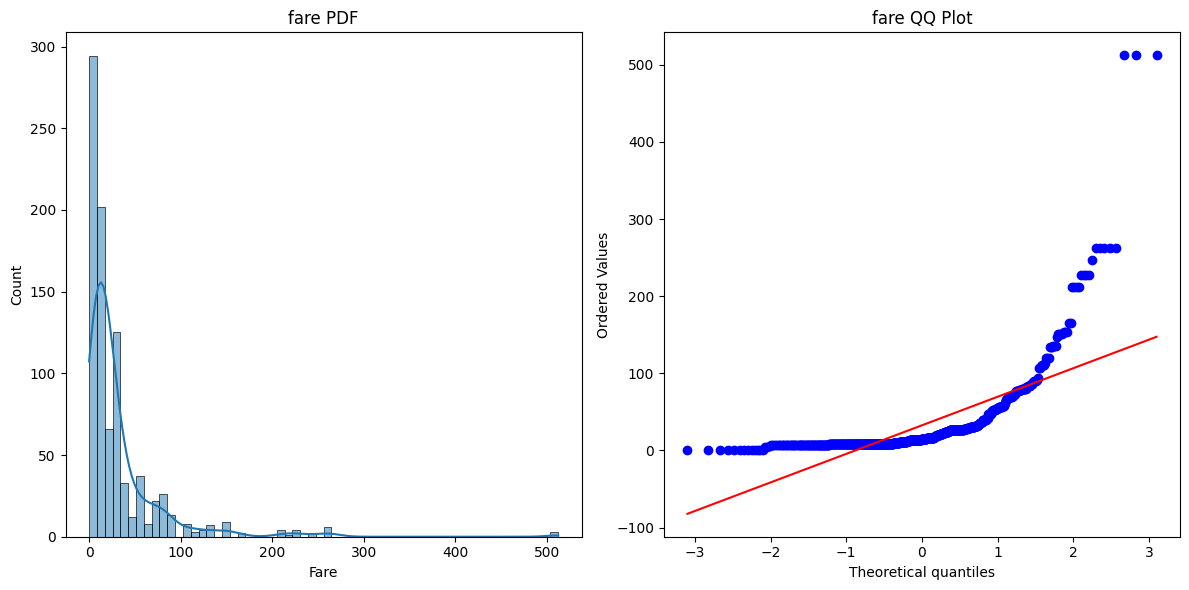

In [20]:
plt.figure(figsize=(12, 6))  # ✅ Correct usage
plt.subplot(121)  # ✅ First subplot
sns.histplot(df["Fare"], kde=True)  # Using histplot instead of displot for subplot compatibility
plt.title("fare PDF")

plt.subplot(122)  # ✅ Second subplot
stats.probplot(x_train["Fare"], dist="norm", plot=plt)
plt.title("fare QQ Plot")

plt.tight_layout()  # Optional: to avoid overlap
plt.show()

In [26]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [22]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred = clf.predict(x_test)
y_pred2 = clf2.predict(x_test)

print("lr : ",accuracy_score(y_pred,y_test))
print("dtc : ", accuracy_score(y_pred2,y_test))

lr :  0.6480446927374302
dtc :  0.6759776536312849


/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


In [23]:
trf =FunctionTransformer(func=np.log1p)

In [24]:
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.fit_transform(x_test)

In [27]:
clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred = clf.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print("lr : ",accuracy_score(y_pred,y_test))
print("dtc : ", accuracy_score(y_pred2,y_test))

lr :  0.6815642458100558
dtc :  0.6871508379888268


/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


In [ ]:
x_transformed = trf.fit_transform(x)

clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print(np.mean(cross_val_score(clf, x_transformed,y,scoring="accuracy",cv=10)))
print(np.mean(cross_val_score(clf2, x_transformed,y,scoring="accuracy",cv=10)))

0.678027465667915
0.6577278401997503


/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_

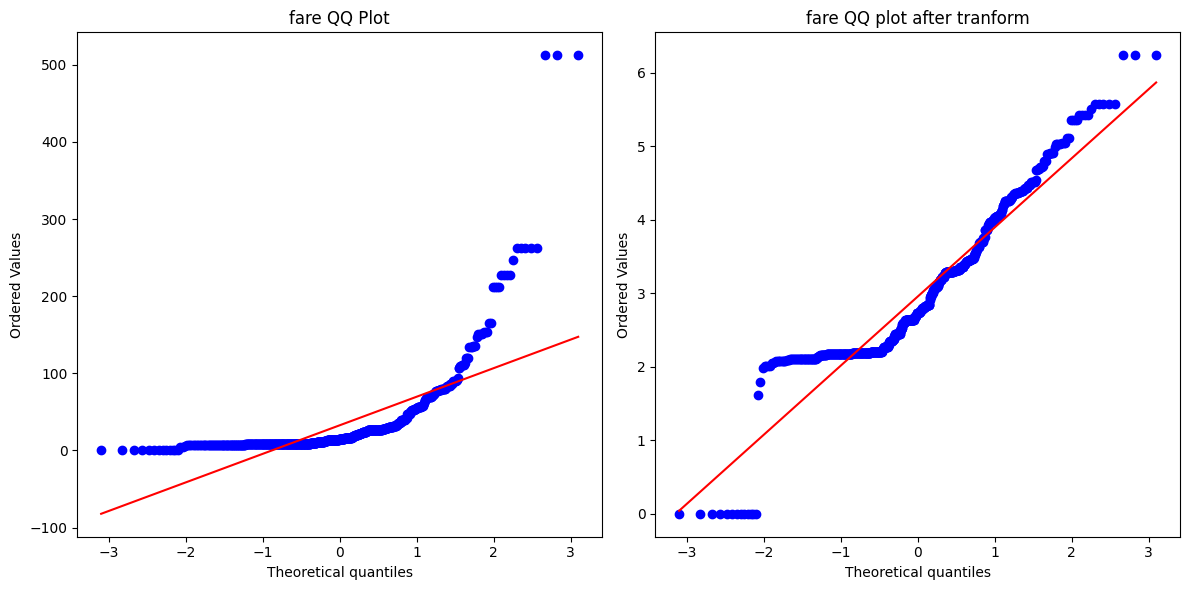

In [29]:
plt.figure(figsize=(12, 6))  # ✅ Correct usage
plt.subplot(121)  # ✅ First subplot
stats.probplot(x_train["Fare"], dist="norm", plot=plt)
plt.title("fare QQ Plot")

plt.subplot(122)  # ✅ Second subplot
stats.probplot(x_train_transformed["Fare"], dist="norm", plot=plt)
plt.title("fare QQ plot after tranform")

plt.tight_layout()  # Optional: to avoid overlap
plt.show()

# power transformer
